# Partie 2 — Deep Learning Fondamental
## Jalon 6 : Optimisation & Hyperparamètres
**Auteur : Hedi MATHLOUTHI**

In [1]:
import sys
import importlib

sys.path.insert(0, '../src')

import itertools
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import torch
import dataset
import models
import training
import utils

importlib.reload(dataset)
importlib.reload(models)
importlib.reload(training)
importlib.reload(utils)

from dataset import ensure_dl_full_data, create_dataloaders, get_class_weights
from models import EmotionCNN
from training import set_seed, get_device, train_model
from utils import save_figure

set_seed(42)
device = get_device()
print(f'Device : {device}')
if device.type == 'cpu':
    print('⚠️  CPU détecté : la recherche 1/16 peut prendre 15–30 min PAR config.')
    print('   → Kernel : Python 3.11 (CUDA) pour utiliser la RTX 5060.')

# Dataset complet (entraînement final)
data_full = ensure_dl_full_data('../data/processed/data_dl_full.pkl')
# Sous-échantillon rapide pour la grille HP uniquement
from dataset import subsample_for_hp_search
data_search = subsample_for_hp_search(data_full, train_fraction=0.35, test_fraction=0.5)
class_weights = get_class_weights(data_search['y_train'])
print(f"Recherche HP : train {data_search['X_train'].shape} | test {data_search['X_test'].shape}")
print(f"Entraînement final : train {data_full['X_train'].shape}")
print('Imports OK')

Device : cpu
⚠️  CPU détecté : la recherche 1/16 peut prendre 15–30 min PAR config.
   → Kernel : Python 3.11 (CUDA) pour utiliser la RTX 5060.
Partie 2 : chargement ../data/processed/data_dl_full.pkl (28709 train)
Recherche HP : train (10048, 2304) | test (3589, 2304)
Entraînement final : train (28709, 2304)
Imports OK


### 1. Justification du choix d'optimiseur

- **Adam** : taux d'apprentissage adaptatif par paramètre → convergence rapide sur CNN
- **SGD + Nesterov** : mise à jour avec momentum, souvent meilleure généralisation mais plus lent

Nous comparons les deux dans la grille ci-dessous.

### 2. Grille de recherche d'hyperparamètres

In [2]:
param_grid = {
    'lr': [1e-3, 5e-4],
    'batch_size': [128, 64],
    'dropout': [0.3, 0.4],
    'optimizer': ['adam', 'sgd'],
}

keys = list(param_grid.keys())
combinations = [dict(zip(keys, v)) for v in itertools.product(*param_grid.values())]
print(f'Nombre de configurations : {len(combinations)}')

Nombre de configurations : 16


### 3. Recherche d'hyperparamètres
> Sur **CPU** ≈ 15–30 min par config (16 configs = plusieurs heures).  
> Sur **GPU** ≈ 2–5 min par config. 

In [3]:
import time as _time

EPOCHS_SEARCH = 8
results_search = []

for i, cfg in enumerate(combinations):
    t0 = _time.time()
    print(f"\n[{i+1}/{len(combinations)}] {cfg}", flush=True)
    train_loader, test_loader = create_dataloaders(
        data_search, batch_size=cfg['batch_size'], mode='image', augment_train=True
    )
    model = EmotionCNN(dropout=cfg['dropout'])
    out = train_model(
        model,
        train_loader,
        test_loader,
        epochs=EPOCHS_SEARCH,
        lr=cfg['lr'],
        optimizer_name=cfg['optimizer'],
        class_weights=class_weights,
        device=device,
        verbose=True,
        show_batch_progress=False,
        early_stop_patience=4,
    )
    elapsed = _time.time() - t0
    results_search.append({**cfg, **{
        'test_acc': out['best_test_acc'],
        'train_time': elapsed,
    }})
    print(f"  → acc={out['best_test_acc']*100:.2f}% | {elapsed/60:.1f} min", flush=True)

df_search = pd.DataFrame(results_search)
df_search = df_search.sort_values('test_acc', ascending=False)
print('\nTop 5 configurations :')
print(df_search.head().to_string(index=False))


[1/16] {'lr': 0.001, 'batch_size': 128, 'dropout': 0.3, 'optimizer': 'adam'}
Epoch 01/8 | train_loss=1.8692 acc=25.24% | test_acc=35.36%
Epoch 02/8 | train_loss=1.6704 acc=36.00% | test_acc=32.35%
Epoch 03/8 | train_loss=1.5143 acc=41.32% | test_acc=38.20%
Epoch 04/8 | train_loss=1.3893 acc=45.75% | test_acc=41.40%
Epoch 05/8 | train_loss=1.3297 acc=48.72% | test_acc=49.43%
Epoch 06/8 | train_loss=1.2555 acc=51.54% | test_acc=48.93%
Epoch 07/8 | train_loss=1.2164 acc=53.09% | test_acc=51.88%
Epoch 08/8 | train_loss=1.1485 acc=55.21% | test_acc=52.16%
  → acc=52.16% | 3.1 min

[2/16] {'lr': 0.001, 'batch_size': 128, 'dropout': 0.3, 'optimizer': 'sgd'}
Epoch 01/8 | train_loss=2.0030 acc=14.36% | test_acc=18.39%
Epoch 02/8 | train_loss=1.9329 acc=18.05% | test_acc=22.35%
Epoch 03/8 | train_loss=1.8990 acc=21.74% | test_acc=26.00%
Epoch 04/8 | train_loss=1.8699 acc=23.88% | test_acc=29.65%
Epoch 05/8 | train_loss=1.8356 acc=25.63% | test_acc=29.84%
Epoch 06/8 | train_loss=1.8172 acc=27.46

### 4. Visualisation de la recherche

Figure sauvegardée : figures/hyperparam_search.png


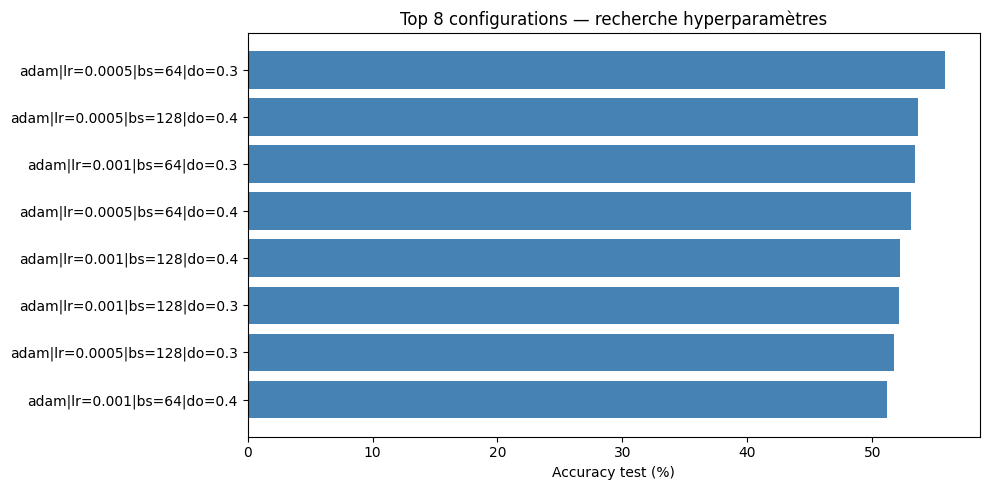

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{r['optimizer']}|lr={r['lr']}|bs={r['batch_size']}|do={r['dropout']}" 
          for _, r in df_search.head(8).iterrows()]
accs = df_search.head(8)['test_acc'] * 100
ax.barh(labels[::-1], accs[::-1], color='steelblue')
ax.set_xlabel('Accuracy test (%)')
ax.set_title('Top 8 configurations — recherche hyperparamètres')
plt.tight_layout()
save_figure('hyperparam_search.png')
plt.show()

### 5. Entraînement final avec la meilleure configuration

In [5]:
best_cfg = df_search.iloc[0].to_dict()
print('Meilleure configuration :')
for k in ['lr', 'batch_size', 'dropout', 'optimizer']:
    print(f'  {k}: {best_cfg[k]}')

class_weights_full = get_class_weights(data_full['y_train'])
train_loader, test_loader = create_dataloaders(
    data_full, batch_size=int(best_cfg['batch_size']), mode='image', augment_train=True
)
best_cnn = EmotionCNN(dropout=float(best_cfg['dropout']))
result_best = train_model(
    best_cnn,
    train_loader,
    test_loader,
    epochs=50,
    lr=float(best_cfg['lr']),
    optimizer_name=str(best_cfg['optimizer']),
    class_weights=class_weights_full,
    device=device,
    early_stop_patience=10,
    verbose=True,
    show_batch_progress=False,
)
print(f"\nAccuracy finale : {result_best['best_test_acc']*100:.2f}%")
print(f"Temps : {result_best['train_time_sec']:.1f}s")

Meilleure configuration :
  lr: 0.0005
  batch_size: 64
  dropout: 0.3
  optimizer: adam
Epoch 01/50 | train_loss=1.6636 acc=36.41% | test_acc=45.36%
Epoch 02/50 | train_loss=1.4276 acc=46.88% | test_acc=51.34%
Epoch 03/50 | train_loss=1.3069 acc=51.12% | test_acc=52.66%
Epoch 04/50 | train_loss=1.2359 acc=53.65% | test_acc=55.49%
Epoch 05/50 | train_loss=1.1911 acc=55.11% | test_acc=58.16%
Epoch 06/50 | train_loss=1.1530 acc=56.21% | test_acc=57.20%
Epoch 07/50 | train_loss=1.1122 acc=57.94% | test_acc=58.76%
Epoch 08/50 | train_loss=1.0771 acc=58.71% | test_acc=58.04%
Epoch 09/50 | train_loss=1.0490 acc=59.09% | test_acc=58.19%
Epoch 10/50 | train_loss=1.0231 acc=60.40% | test_acc=60.96%
Epoch 11/50 | train_loss=1.0028 acc=61.46% | test_acc=60.27%
Epoch 12/50 | train_loss=0.9857 acc=62.08% | test_acc=59.04%
Epoch 13/50 | train_loss=0.9503 acc=63.28% | test_acc=61.03%
Epoch 14/50 | train_loss=0.9365 acc=64.25% | test_acc=59.53%
Epoch 15/50 | train_loss=0.9062 acc=64.38% | test_acc=60.

### 6. Sauvegarde du modèle optimisé

In [6]:
import os
os.makedirs('../data/processed', exist_ok=True)
torch.save(result_best['model'].state_dict(), '../data/processed/cnn_best.pt')

with open('../data/processed/opti_dl_results.pkl', 'wb') as f:
    pickle.dump({
        'best_config': best_cfg,
        'search_results': results_search,
        'final_acc': result_best['best_test_acc'],
        'final_time': result_best['train_time_sec'],
        'history': result_best['history'],
        'y_true': result_best['y_true'],
        'y_pred': result_best['y_pred'],
    }, f)
print('Résultats opti-dl sauvegardés.')

Résultats opti-dl sauvegardés.
